# RE1.2 · El conjunto curado y particionado

Qué hay en `data/processed/`: cómo se eligen las 25 clases, cómo se reparten las grabaciones en
train/val/test, qué hace el ventaneo de 3 s y cómo queda cada partición. Cifras y figuras de
`RE_1-2_conjunto-particionado.tex`.

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import reporte
import torch
from matplotlib.patches import Rectangle
from reporte import TEXT_WIDTH_IN, number, percent, scalar

from core.config import PROCESSED_DIR, RAW_DIR, P
from data import cache
from data.annotations import load_annotations
from data.species import CALL_TYPES, VALID_PAIRS
from prepare_data import (
    EMPTY_RATIO,
    EXCLUDED_LABELS,
    JOINED_LABELS,
    MIN_PAIR_COUNT,
    SPLIT_RATIOS,
    select_experiment,
)
from utils.audio import mel_to_db

OUT = reporte.out_dir("RE_1-2")
SPLIT_NAMES = {"train": "Entrenamiento", "val": "Validación", "test": "Prueba"}
EDGE = 1e-3  # una caja toca el borde temporal de la ventana si su lado queda a menos de esto

In [2]:
annotations = load_annotations()
experiment, labels = select_experiment(annotations)
experiment = experiment.assign(
    recording=[str(Path(p).relative_to(RAW_DIR)) for p in experiment["audio_path"]]
)

# cleaned/ no guarda la bandera de revisión: el par se contrasta acá con el vocabulario.
in_vocabulary = pd.Series(
    list(zip(annotations["species"], annotations["call_type"], strict=True))
).isin(VALID_PAIRS)
label = (annotations["species"] + "/" + annotations["call_type"]).replace(JOINED_LABELS)
counts = label[in_vocabulary.to_numpy()].value_counts()
selection = pd.DataFrame({"anotaciones": counts})
selection["destino"] = np.select(
    [selection.index.isin(EXCLUDED_LABELS), selection["anotaciones"] >= MIN_PAIR_COUNT],
    ["excluida (frase)", "clase"],
    default=f"$<{MIN_PAIR_COUNT}$ anotaciones",
)
print(
    f"{len(annotations)} anotaciones en cleaned/ · {len(counts)} pares en vocabulario · "
    f"{len(labels)} clases con {len(experiment)} anotaciones"
)
selection["destino"].value_counts()

19031 anotaciones en cleaned/ · 37 pares en vocabulario · 25 clases con 17616 anotaciones


destino
clase                 25
$<100$ anotaciones    10
excluida (frase)       2
Name: count, dtype: int64

In [3]:
# Los tres .pt se abren con mmap: se leen cajas y etiquetas sin traer los mel a memoria.
def read_split(name: str) -> dict:
    return torch.load(cache.split_path(name), map_location="cpu", mmap=True, weights_only=True)


splits = {name: read_split(name) for name in cache.SPLITS}
sources = {name: cache.sources(name, len(data["images"])) for name, data in splits.items()}
recordings = {
    name: {str(Path(p).relative_to(RAW_DIR)) for p in found.recordings}
    for name, found in sources.items()
}
overlap = {
    f"{a} ∩ {b}": len(recordings[a] & recordings[b])
    for a, b in (("train", "val"), ("train", "test"), ("val", "test"))
}
assert not any(overlap.values()), overlap
n_boxes = {name: [len(b) for b in data["boxes"]] for name, data in splits.items()}
composition = pd.DataFrame(
    {
        "grabaciones": {name: len(r) for name, r in recordings.items()},
        "ventanas": {name: len(n) for name, n in n_boxes.items()},
        "ventanas vacías": {name: sum(1 for n in ns if n == 0) for name, ns in n_boxes.items()},
        "cajas": {name: sum(ns) for name, ns in n_boxes.items()},
        "GB": {name: cache.split_path(name).stat().st_size / 1024**3 for name in splits},
    }
)
composition.loc["total"] = composition.sum()
reporte.write_rows(
    OUT / "particiones.tex",
    [
        (
            SPLIT_NAMES.get(str(name), "Total"),
            number(row.grabaciones),
            number(row.ventanas),
            number(row["ventanas vacías"]),
            percent(row["ventanas vacías"] / row.ventanas),
            number(row.cajas),
            number(row.GB, 2),
        )
        for name, row in composition.iterrows()
    ],
)
print(overlap)
composition.round(2)

{'train ∩ val': 0, 'train ∩ test': 0, 'val ∩ test': 0}


,grabaciones,ventanas,ventanas vacías,cajas,GB
train,1264.0,21830.0,4614.0,27062.0,3.46
val,675.0,9356.0,2700.0,10122.0,1.48
test,602.0,7599.0,2382.0,7924.0,1.20
total,2541.0,38785.0,9696.0,45108.0,6.14


In [4]:
# Por clase: anotaciones (cleaned/) y cajas por partición (ventanas del caché).
split_of = {r: name for name, rs in recordings.items() for r in rs}
experiment["split"] = experiment["recording"].map(split_of)
boxes_by_class = (
    pd.DataFrame(
        {
            name: pd.Series(torch.cat(data["labels"]).numpy()).value_counts()
            for name, data in splits.items()
        }
    )
    .fillna(0)
    .astype(int)
)
boxes_by_class.index = pd.Index([labels.name(i) for i in boxes_by_class.index])
per_class = pd.DataFrame(
    {
        "anotaciones": experiment["label"].value_counts(),
        "grabaciones": experiment.groupby("label")["recording"].nunique(),
    }
).join(boxes_by_class[list(cache.SPLITS)])
per_class["cajas"] = per_class[list(cache.SPLITS)].sum(axis=1)
per_class["cajas/anot."] = per_class["cajas"] / per_class["anotaciones"]
per_class["train %"] = per_class["train"] / per_class["cajas"]
per_class = per_class.sort_values("anotaciones", ascending=False)

readable = {
    f"{species.name.lower()}/{code}": name.replace("_", " ")
    for species, codes in CALL_TYPES.items()
    for code, name in codes.items()
}
readable["lw/trino"] = "trino (tr, tj, tt, tf)"
readable["sb/ppc"] = "play peep call (ppc, lpc)"
reporte.write_rows(
    OUT / "clases.tex",
    [
        (
            f"\\texttt{{{name}}}",
            readable[str(name)],
            number(row.anotaciones),
            number(row.grabaciones),
            number(row.train),
            number(row.val),
            number(row.test),
            percent(row["train %"], 0),
        )
        for name, row in per_class.iterrows()
    ]
    + [
        (
            "\\textbf{Total}",
            "",
            number(per_class.anotaciones.sum()),
            number(experiment["recording"].nunique()),
            number(per_class.train.sum()),
            number(per_class.val.sum()),
            number(per_class.test.sum()),
            percent(per_class.train.sum() / per_class.cajas.sum(), 0),
        )
    ],
)
per_class.round(2)

,anotaciones,grabaciones,train,val,test,cajas,cajas/anot.,train %
label,,,,,,,,
ac/bc,2487,138,2886,1082,842,4810,1.93,0.60
lw/cs,2282,248,2668,1000,778,4446,1.95,0.60
sm/cc,2040,467,2359,884,688,3931,1.93,0.60
as/bc,1909,237,2233,837,651,3721,1.95,0.60
as/hc,1400,706,6932,2599,2022,11553,8.25,0.60
sb/ppc,1200,192,1387,514,432,2333,1.94,0.59
aa/gc,799,58,921,345,270,1536,1.92,0.60
sb/spc,729,166,859,323,250,1432,1.96,0.60
sm/fs,691,89,799,300,233,1332,1.93,0.60


In [5]:
# Pares del vocabulario que no entran: por anidamiento (frases) o por quedar bajo el umbral.
left_out = selection.loc[selection["destino"] != "clase"].sort_values(
    "anotaciones", ascending=False
)
reporte.write_rows(
    OUT / "excluidas.tex",
    [
        (f"\\texttt{{{name}}}", readable.get(str(name), ""), number(row.anotaciones), row.destino)
        for name, row in left_out.iterrows()
    ],
)
left_out

,anotaciones,destino
lw/cc,536,excluida (frase)
sm/fc,126,excluida (frase)
lw/aa,80,$<100$ anotaciones
sm/whc,76,$<100$ anotaciones
pt/ac,44,$<100$ anotaciones
pt/pp,43,$<100$ anotaciones
pt/bp,39,$<100$ anotaciones
ac/whc,35,$<100$ anotaciones
lw/phc,34,$<100$ anotaciones
ac/cc,29,$<100$ anotaciones


In [6]:
# Qué le cuesta el ventaneo a cada clase: cajas por anotación y cuántas cajas tocan un borde
# temporal de la ventana (la llamada sigue fuera de ella).
def edge_fraction(name: str) -> float:
    boxes = torch.cat([b for b in splits[name]["boxes"] if len(b)])
    x0, x1 = boxes[:, 0] - boxes[:, 2] / 2, boxes[:, 0] + boxes[:, 2] / 2
    return float(((x0 <= EDGE) | (x1 >= 1 - EDGE)).float().mean())


all_boxes = torch.cat([b for data in splits.values() for b in data["boxes"] if len(b)])
all_labels = torch.cat([lab for data in splits.values() for lab in data["labels"]])
at_edge = (all_boxes[:, 0] - all_boxes[:, 2] / 2 <= EDGE) | (
    all_boxes[:, 0] + all_boxes[:, 2] / 2 >= 1 - EDGE
)
full_width = all_boxes[:, 2] >= 1 - 2 * EDGE
windowing = pd.DataFrame(
    {
        "anotaciones": per_class["anotaciones"],
        "cajas": per_class["cajas"],
        "cajas por anotación": per_class["cajas/anot."],
        "> 3 s": experiment.groupby("label")["duration_s"].apply(
            lambda d: (d > P.clip_len_s).mean()
        ),
        "en el borde": pd.Series(at_edge.numpy())
        .groupby(all_labels.numpy())
        .mean()
        .rename(labels.name),
        "ventana entera": pd.Series(full_width.numpy())
        .groupby(all_labels.numpy())
        .mean()
        .rename(labels.name),
    }
).sort_values("cajas por anotación", ascending=False)
long_classes = windowing.index[windowing["> 3 s"] > 0.5].tolist()
rest = windowing.drop(index=long_classes)
summary_rows = [
    (
        f"\\texttt{{{name}}}",
        number(r.anotaciones),
        number(r.cajas),
        number(r["cajas por anotación"], 1),
        percent(r["> 3 s"]),
        percent(r["en el borde"]),
        percent(r["ventana entera"]),
    )
    for name, r in windowing.loc[long_classes].iterrows()
] + [
    (
        f"Resto ({len(rest)} clases)",
        number(rest.anotaciones.sum()),
        number(rest.cajas.sum()),
        number(rest.cajas.sum() / rest.anotaciones.sum(), 1),
        percent((rest["> 3 s"] * rest.anotaciones).sum() / rest.anotaciones.sum()),
        percent((rest["en el borde"] * rest.cajas).sum() / rest.cajas.sum()),
        percent((rest["ventana entera"] * rest.cajas).sum() / rest.cajas.sum()),
    ),
    (
        "\\textbf{Total}",
        number(windowing.anotaciones.sum()),
        number(windowing.cajas.sum()),
        number(windowing.cajas.sum() / windowing.anotaciones.sum(), 1),
        percent((windowing["> 3 s"] * windowing.anotaciones).sum() / windowing.anotaciones.sum()),
        percent(float(at_edge.float().mean())),
        percent(float(full_width.float().mean())),
    ),
]
reporte.write_rows(OUT / "ventaneo.tex", summary_rows)
windowing.round(3)

,anotaciones,cajas,cajas por anotación,> 3 s,en el borde,ventana entera
as/hc,1400,11553,8.252,0.946,0.996,0.775
pt/dc,635,3240,5.102,0.910,0.992,0.635
ac/gc,140,318,2.271,0.171,0.557,0.138
sb/sc,105,209,1.990,0.000,0.172,0.000
sm/sc,168,334,1.988,0.036,0.260,0.015
ac/chc,236,468,1.983,0.034,0.421,0.009
ac/sc,158,313,1.981,0.019,0.438,0.019
lw/sqc,154,303,1.968,0.000,0.314,0.000
sb/spc,729,1432,1.964,0.000,0.055,0.000
sb/pcc,290,569,1.962,0.003,0.281,0.004


In [7]:
# Cajas por ventana (sólo ventanas con al menos una) y el presupuesto de consultas del decoder.
per_window = pd.Series([n for ns in n_boxes.values() for n in ns if n > 0])
histogram = (
    per_window.value_counts().sort_index().rename_axis("cajas").rename("ventanas").reset_index()
)
reporte.write_data(OUT / "cajas_por_ventana", histogram)
print(
    f"mediana {per_window.median():.0f} · p97 {per_window.quantile(0.97):.0f} · máximo {per_window.max()}"
)
histogram.T

mediana 1 · p97 4 · máximo 11


,0,1,2,3,4,5,6,7,8,9,10
cajas,1,2,3,4,5,6,7,8,9,10,11
ventanas,20803,3846,2499,1129,466,227,67,35,12,4,1


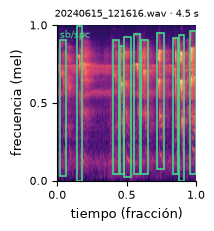

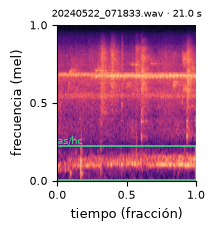

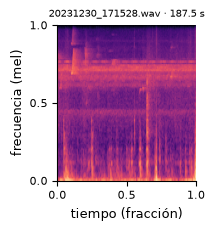

In [8]:
# Tres ventanas de entrenamiento tal como las recibe el modelo: la más densa, una de llamada
# larga cortada por los dos bordes y una vacía.
train = splits["train"]
train_counts = np.array(n_boxes["train"])
densest = int(train_counts.argmax())
long_label = labels.id(long_classes[0])
long_window = next(
    i
    for i, (b, lab) in enumerate(zip(train["boxes"], train["labels"], strict=True))
    if len(b) == 1 and int(lab[0]) == long_label and float(b[0, 2]) >= 1 - 2 * EDGE
)
empty = int(np.flatnonzero(train_counts == 0)[0])
examples = [(densest, "ventana_densa"), (long_window, "ventana_larga"), (empty, "ventana_vacia")]

# Una imagen por ventana, del ancho de una subfigura (un tercio del texto), para que el
# documento las coloque por separado.
for index, name in examples:
    fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN / 3, 2.2), constrained_layout=True)
    ax.imshow(
        mel_to_db(train["images"][index, 0]).numpy(),
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=(0, 1, 0, 1),
    )
    seen: set[int] = (
        set()
    )  # una etiqueta por clase y ventana: once cajas iguales no se rotulan once veces
    for (cx, cy, w, h), lab in zip(
        train["boxes"][index].tolist(), train["labels"][index].tolist(), strict=True
    ):
        ax.add_patch(
            Rectangle(
                (cx - w / 2, cy - h / 2), w, h, fill=False, edgecolor="#3ddc84", linewidth=1.2
            )
        )
        if lab not in seen:
            seen.add(lab)
            ax.text(
                cx - w / 2,
                min(cy + h / 2, 0.96),
                labels.name(lab),
                color="#3ddc84",
                fontsize=7,
                va="bottom",
            )
    recording, start = (
        sources["train"].recordings[sources["train"].recording_of_window[index]],
        sources["train"].clip_start_s[index],
    )
    ax.set_title(f"{Path(recording).name} · {start:.1f} s", fontsize=7)
    ax.set(
        xlabel="tiempo (fracción)",
        ylabel="frecuencia (mel)",
        xticks=[0, 0.5, 1],
        yticks=[0, 0.5, 1],
    )
    ax.grid(False)
    reporte.save_figure(fig, OUT / name)
    plt.show()

In [9]:
shutil.copy(PROCESSED_DIR / "meta.json", OUT / "meta.json")
meta = cache.meta()


def total(column: str, split: str = "total") -> float:
    return scalar(composition, split, column)


reporte.write_macros(
    OUT / "valores.tex",
    {
        "n_annotations_cleaned": number(len(annotations)),
        "n_vocab_pairs": number(len(counts)),
        "n_classes": number(len(labels)),
        "n_experiment": number(len(experiment)),
        "pct_experiment": percent(len(experiment) / int(counts.sum())),
        "n_left_out": number(len(left_out)),
        "n_left_out_annotations": number(int(left_out.anotaciones.sum())),
        "n_below_threshold": number(int((left_out.destino != "excluida (frase)").sum())),
        "n_recordings": number(experiment["recording"].nunique()),
        "n_windows": number(total("ventanas")),
        "n_boxes": number(total("cajas")),
        "n_empty": number(total("ventanas vacías")),
        "pct_empty": percent(total("ventanas vacías") / total("ventanas")),
        "n_windows_train": number(total("ventanas", "train")),
        "n_windows_val": number(total("ventanas", "val")),
        "n_windows_test": number(total("ventanas", "test")),
        "n_boxes_train": number(total("cajas", "train")),
        "n_boxes_val": number(total("cajas", "val")),
        "n_boxes_test": number(total("cajas", "test")),
        "gb_total": number(total("GB"), 1),
        "boxes_per_annotation": number(
            float(windowing.cajas.sum() / windowing.anotaciones.sum()), 1
        ),
        "long_classes": ", ".join(f"\\texttt{{{c}}}" for c in long_classes),
        "pct_long_boxes": percent(
            windowing.loc[long_classes, "cajas"].sum() / windowing.cajas.sum(), 0
        ),
        "median_per_window": number(float(per_window.median())),
        "max_per_window": number(int(per_window.max())),
        "pct_leq_four": percent((per_window <= 4).mean(), 0),
        "largest_class": f"\\texttt{{{per_class.index[0]}}}",
        "largest_class_train": number(int(per_class.train.iloc[0])),
        "smallest_class": f"\\texttt{{{per_class.index[-1]}}}",
        "smallest_class_train": number(int(per_class.train.iloc[-1])),
        "n_small_classes": number(int((per_class.train < 300).sum())),
        "db_low": number(meta["db_range"][0], 1),
        "db_high": number(meta["db_range"][1], 1),
        "split_ratios": " / ".join(number(100 * r, 1) for r in SPLIT_RATIOS),
        "empty_ratio": percent(EMPTY_RATIO, 0),
        "min_pair_count": number(MIN_PAIR_COUNT),
        "seed": number(meta["seed"]),
    },
)
sorted(OUT.iterdir())

[PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/cajas_por_clase.dat'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/cajas_por_ventana.dat'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/clases.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/excluidas.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/meta.json'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/particiones.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/valores.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/ventana_densa.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/ventana_larga.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/ventana_vacia.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_1-2/ventanas